In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.1 MB/s eta 0:00:00


In [2]:
!pip install --upgrade scikit-learn

In [3]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.6/233.6 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 3.7 MB/s eta 0:00:00


In [4]:
pip install dask[dataframe]

INFO: pip is looking at multiple versions of dask-expr to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.2/243.2 kB 6.1 MB/s eta 0:00:00


In [5]:
!pip install --upgrade scikit-learn xgboost

In [6]:
### Step 1: Import Required Libraries
# Import essential libraries for data manipulation, model training, and evaluation
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
import optuna
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files

In [7]:
### Step 2: Upload Dataset to Google Colab
# Upload the processed dataset manually in Google Colab
uploaded = files.upload()



Saving final_processed_data.csv to final_processed_data.csv


In [8]:
# Load the dataset
df = pd.read_csv("final_processed_data.csv")

In [9]:
### Step 3: Prepare Data
# Drop unnecessary columns that do not contribute to model training
df.drop(columns=["Unnamed: 0", "surge_multiplier", "cancellation_fee", "time_of_day"], inplace=True)

In [10]:
### Step 4: Encode Categorical Features
# Convert categorical variables into numerical values using Label Encoding
categorical_cols = ["day_of_week", "weather_condition", "vehicle_type", "pickup_location_type", "dropoff_location_type"]
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le  # Store encoder for future use

In [11]:
### Step 5: Define Features and Targets
# Select the target variables and features for model training
targets = ["trip_duration_min", "total_fare", "traffic_index"]
X = df.drop(columns=targets)
y = df[targets]

In [12]:
### Step 6: Split Data into Training and Testing Sets
# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
## Step 7: Initialize and Train Models
# Initialize machine learning models
# Initialize XGBoost and CatBoost (they support multi-output training)
xgb_model = xgb.XGBRegressor()
cb_model = cb.CatBoostRegressor(verbose=0, loss_function='MultiRMSE') # Add loss_function here

# Train separate LightGBM models for each target variable
lgb_models = {}  # Dictionary to store trained models for each target
for target in y_train.columns:
    lgb_models[target] = lgb.LGBMRegressor()
    lgb_models[target].fit(X_train, y_train[target])  # Train separately for each target

# Train XGBoost and CatBoost
xgb_model.fit(X_train, y_train)
cb_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002014 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5632
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 28
[LightGBM] [Info] Start training from score -0.000834
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002875 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5632
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 28
[LightGBM] [Info] Start training from score -0.003788
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004674 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5632
[LightGBM] [Info] Number of data points in the train set

In [14]:
### Step 8: Predict on Test Set
# Generate predictions for test data
# Predict separately for each target using LightGBM
y_pred_lgb = pd.DataFrame({target: lgb_models[target].predict(X_test) for target in y_test.columns})

# Predict using XGBoost and CatBoost
y_pred_xgb = xgb_model.predict(X_test)
y_pred_cb = cb_model.predict(X_test)


In [15]:
### Step 9: Evaluate Model Performance
# Function to calculate and display model performance metrics
def evaluate(y_true, y_pred, model_name):
    print(f"{model_name} Metrics:")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R^2 Score:", r2_score(y_true, y_pred))
    print("-" * 50)

In [16]:
# Evaluate each model
evaluate(y_test, y_pred_lgb, "LightGBM")
evaluate(y_test, y_pred_xgb, "XGBoost")
evaluate(y_test, y_pred_cb, "CatBoost")

LightGBM Metrics:
MAE: 0.8243821283874088
RMSE: 0.9976678107877895
R^2 Score: 0.0055447218782105345
--------------------------------------------------
XGBoost Metrics:
MAE: 0.8636088371276855
RMSE: 1.056411182362146
R^2 Score: -0.11495842784643173
--------------------------------------------------
CatBoost Metrics:
MAE: 0.8144625358596294
RMSE: 0.9825214840073441
R^2 Score: 0.03558293487123365
--------------------------------------------------


In [17]:
### Step 10: Hyperparameter Tuning with Optuna
import optuna
import catboost as cb
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split

# Corrected objective function for Optuna tuning of CatBoostRegressor
def objective(trial):
    # Define the hyperparameters to tune for CatBoost
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000, step=100),
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 0.3),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_loguniform("l2_leaf_reg", 1e-3, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_uniform("random_strength", 1, 10),
        "bagging_temperature": trial.suggest_uniform("bagging_temperature", 0.0, 1.0),
        "verbose": 0,  # Suppress training logs
        "early_stopping_rounds": 50  # Early stopping if no improvement
    }

    # Initialize the CatBoost model with the suggested parameters
    model = cb.CatBoostRegressor(**params)

    # Train the model on the training data
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid))

    # Predict and calculate Mean Absolute Error (MAE)
    preds = model.predict(X_valid)
    mae = mean_absolute_error(y_valid, preds)

    return mae  # We want to minimize MAE

In [18]:
print("Shape of y_train:", y_train.shape)


Shape of y_train: (8000, 3)


In [19]:
# Example: Selecting 'total_fare' for fare prediction
y_train = y_train['total_fare'].values.ravel()


In [20]:
print("Updated y_train shape:", y_train.shape)


Updated y_train shape: (8000,)


In [41]:
# Run optimization for 20 trials
import optuna
import logging
import time

# Enable real-time logging
optuna.logging.set_verbosity(optuna.logging.INFO)

# Define objective function
def objective(trial):
    x = trial.suggest_float('x', -10, 10)
    result = (x - 2) ** 2  # Example function to minimize
    print(f"Trial {trial.number}: x = {x:.4f}, Loss = {result:.4f}", flush=True)  # Ensures real-time output
    return result

# Define a callback to print after each trial
def callback(study, trial):
    print(f"Completed Trial {trial.number+1}: Best Value = {study.best_value:.4f}", flush=True)

# Start timing for performance measurement
start_time = time.time()

# Run optimization for 20 trials
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=500, callbacks=[callback])

# Print total execution time
end_time = time.time()
print(f"\nOptimization Completed in {end_time - start_time:.2f} seconds.")


[I 2025-02-21 13:42:28,148] A new study created in memory with name: no-name-a0e89f79-add9-455c-a26b-9735501e4631


Trial 0: x = -3.4912, Loss = 30.1532


[I 2025-02-21 13:42:28,154] Trial 0 finished with value: 30.153214421300785 and parameters: {'x': -3.4911942618433}. Best is trial 0 with value: 30.153214421300785.


Completed Trial 1: Best Value = 30.1532
Trial 1: x = -4.5597, Loss = 43.0301


[I 2025-02-21 13:42:28,160] Trial 1 finished with value: 43.03011345406728 and parameters: {'x': -4.559734251786979}. Best is trial 0 with value: 30.153214421300785.


...

Completed Trial 498: Best Value = 0.0000
Trial 498: x = 1.9528, Loss = 0.0022


[I 2025-02-21 13:42:35,643] Trial 498 finished with value: 0.0022286606303701583 and parameters: {'x': 1.9527913076820576}. Best is trial 465 with value: 3.59833646244326e-07.


Completed Trial 499: Best Value = 0.0000
Trial 499: x = 2.3853, Loss = 0.1485


[I 2025-02-21 13:42:35,662] Trial 499 finished with value: 0.14847649850163291 and parameters: {'x': 2.3853264830006276}. Best is trial 465 with value: 3.59833646244326e-07.


Completed Trial 500: Best Value = 0.0000

Optimization Completed in 7.52 seconds.


In [22]:
# Get the best hyperparameters and print them
best_params = study.best_params
print("Best Hyperparameters for CatBoost:", best_params)

Best Hyperparameters for CatBoost: {'x': 1.338930546291099}


In [26]:
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


y_train shape: (8000,)
y_test shape: (6000,)


In [27]:
import numpy as np

print("NaN values in y_train:", np.isnan(y_train).sum())
print("NaN values in y_test:", np.isnan(y_test).sum())

# Drop rows with NaN in y_train and corresponding X_train rows
non_nan_indices = ~np.isnan(y_train)
X_train = X_train[non_nan_indices]
y_train = y_train[non_nan_indices]


NaN values in y_train: 0
NaN values in y_test: 0


In [28]:
from sklearn.model_selection import train_test_split

# Assuming 'trip_duration_min' is your target column
total_fare = 'trip_duration_min'

# Separate features and target
X = df.drop(columns=[total_fare])
y = df[total_fare]

# Perform the train-test split again
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape y_train and y_test
y_train = y_train.ravel()
y_test = y_test.ravel()


<ipython-input-28-bc77dd3f83b5>:14: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_train = y_train.ravel()
<ipython-input-28-bc77dd3f83b5>:15: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  y_test = y_test.ravel()


In [29]:
X_train = X_train.drop(columns=['surge_multiplier', 'time_of_day', 'cancellation_fee'], errors='ignore')
X_test = X_test.drop(columns=['surge_multiplier', 'time_of_day', 'cancellation_fee'], errors='ignore')


In [30]:
X_train.fillna(X_train.mean(), inplace=True)
X_test.fillna(X_test.mean(), inplace=True)


In [32]:
print("Best Hyperparameters from Optuna:", best_params)


Best Hyperparameters from Optuna: {'x': 1.338930546291099}


In [33]:
# Remove any unexpected keys
valid_params = {k: v for k, v in best_params.items() if k in [
    "iterations", "learning_rate", "depth", "l2_leaf_reg",
    "border_count", "random_strength", "bagging_temperature"
]}

print("Filtered Best Parameters:", valid_params)


Filtered Best Parameters: {}


In [34]:
best_catboost = cb.CatBoostRegressor(**valid_params, verbose=100)
best_catboost.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=20)


Learning rate set to 0.07058
0:	learn: 0.9655174	test: 0.9514988	best: 0.9514988 (0)	total: 10.8ms	remaining: 10.8s
100:	learn: 0.5217502	test: 0.5508039	best: 0.5508039 (100)	total: 792ms	remaining: 7.05s
200:	learn: 0.4800825	test: 0.5436469	best: 0.5436200 (199)	total: 1.54s	remaining: 6.14s
Stopped by overfitting detector  (20 iterations wait)

bestTest = 0.543430835
bestIteration = 202

Shrink model to first 203 iterations.


In [35]:
best_catboost.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=50  # Increase from 20 to 50
)


Learning rate set to 0.07058
0:	learn: 0.9655174	test: 0.9514988	best: 0.9514988 (0)	total: 8.13ms	remaining: 8.12s
100:	learn: 0.5217502	test: 0.5508039	best: 0.5508039 (100)	total: 788ms	remaining: 7.01s
200:	learn: 0.4800825	test: 0.5436469	best: 0.5436200 (199)	total: 1.58s	remaining: 6.3s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.543430835
bestIteration = 202

Shrink model to first 203 iterations.


In [38]:
from sklearn.model_selection import cross_val_score


In [40]:
import optuna
import catboost as cb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Split a small portion of data for fast tuning
X_train_sample, X_valid_sample, y_train_sample, y_valid_sample = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 2000, step=500),  # ✅ Reduce range
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "depth": trial.suggest_int("depth", 3, 8),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "verbose": 0
    }

    model = cb.CatBoostRegressor(**params)
    model.fit(X_train_sample, y_train_sample, eval_set=(X_valid_sample, y_valid_sample), early_stopping_rounds=10, verbose=0)  # ✅ Early stopping
    y_pred = model.predict(X_valid_sample)

    return mean_absolute_error(y_valid_sample, y_pred)  # ✅ Faster single evaluation

# Fast Optuna optimization with 15 trials
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=15)  # ✅ Reduce trials

# Get best parameters
best_params = study.best_params
print("Best Hyperparameters for CatBoost (Fast Optimization):", best_params)


[I 2025-02-21 13:41:27,858] A new study created in memory with name: no-name-f0dc07d1-bbeb-4c1e-88ef-9c31e903fdc8
[I 2025-02-21 13:41:29,127] Trial 0 finished with value: 0.34765687558039615 and parameters: {'iterations': 1500, 'learning_rate': 0.022656148220890356, 'depth': 3, 'l2_leaf_reg': 0.0035374362435697778, 'border_count': 54, 'random_strength': 1.852341102699465, 'bagging_temperature': 0.9502848457855232}. Best is trial 0 with value: 0.34765687558039615.
[I 2025-02-21 13:41:30,346] Trial 1 finished with value: 0.3410195267870197 and parameters: {'iterations': 2000, 'learning_rate': 0.05464055625866338, 'depth': 5, 'l2_leaf_reg': 7.153223629757798, 'border_count': 186, 'random_strength': 6.011027749372163, 'bagging_temperature': 0.04785190138051032}. Best is trial 1 with value: 0.3410195267870197.
[I 2025-02-21 13:41:31,609] Trial 2 finished with value: 0.4444607426855083 and parameters: {'iterations': 500, 'learning_rate': 0.009793584679725905, 'depth': 4, 'l2_leaf_reg': 0.031

Best Hyperparameters for CatBoost (Fast Optimization): {'iterations': 2000, 'learning_rate': 0.09957636452284852, 'depth': 5, 'l2_leaf_reg': 0.13143920467719444, 'border_count': 146, 'random_strength': 2.320915103627338, 'bagging_temperature': 0.3895842877771261}


In [44]:
print("Best Hyperparameters from Optuna:", best_params)

Best Hyperparameters from Optuna: {'x': 2.0005998613558518}


In [45]:
# Get best hyperparameters from Optuna
best_params = study.best_params

# Print best hyperparameters
print("Best Hyperparameters from Optuna:", best_params)


Best Hyperparameters from Optuna: {'x': 2.0005998613558518}


In [46]:
print("Best Hyperparameters from Optuna:", study.best_params)  # Should return a dictionary
print("Best Validation Loss:", study.best_value)  # Should return a number (like 2.0006)


Best Hyperparameters from Optuna: {'x': 2.0005998613558518}
Best Validation Loss: 3.59833646244326e-07


In [47]:
import optuna
import catboost as cb
from sklearn.model_selection import cross_val_score
import time

# Define the Optuna objective function for CatBoost
def objective(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 500, 5000, step=500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-3, 10.0, log=True),
        "border_count": trial.suggest_int("border_count", 32, 255),
        "random_strength": trial.suggest_float("random_strength", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 1.0),
        "verbose": 0
    }

    model = cb.CatBoostRegressor(**params)

    # Use cross-validation to evaluate model performance
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring="neg_mean_absolute_error")

    return -scores.mean()  # Minimize MAE (Mean Absolute Error)



In [53]:
from catboost import CatBoostRegressor

print(CatBoostRegressor().get_param('task_type'))



None


In [55]:
!nvidia-smi


/bin/bash: line 1: nvidia-smi: command not found


In [58]:
import catboost

task_type = "GPU" if catboost.utils.is_cuda_available() else "CPU"

best_catboost = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.09957636452284852,
    depth=5,
    l2_leaf_reg=0.13143920467719444,
    border_count=146,
    random_strength=2.320915103627338,
    bagging_temperature=0.3895842877771261,
    task_type=task_type,  # Automatically switch
    verbose=100
)

print(f"Using {task_type} for training.")
best_catboost.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=15)


AttributeError: module 'catboost' has no attribute 'utils'

In [59]:
import catboost
import os

# Check if GPU is available
gpu_available = os.system("nvidia-smi") == 0  # Returns 0 if GPU is detected

task_type = "GPU" if gpu_available else "CPU"

print(f"Using {task_type} for training.")

best_catboost = catboost.CatBoostRegressor(
    iterations=2000,
    learning_rate=0.09957636452284852,
    depth=5,
    l2_leaf_reg=0.13143920467719444,
    border_count=146,
    random_strength=2.320915103627338,
    bagging_temperature=0.3895842877771261,
    task_type=task_type,  # Automatically select GPU or CPU
    verbose=100
)

best_catboost.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=15)


Using CPU for training.
0:	learn: 0.9553773	test: 0.9407201	best: 0.9407201 (0)	total: 8.16ms	remaining: 16.3s
100:	learn: 0.5287645	test: 0.5590371	best: 0.5590371 (100)	total: 445ms	remaining: 8.37s
Stopped by overfitting detector  (15 iterations wait)

bestTest = 0.5515333376
bestIteration = 137

Shrink model to first 138 iterations.


In [60]:
best_catboost.fit(X_train, y_train, eval_set=(X_test, y_test), early_stopping_rounds=50)


0:	learn: 0.9553773	test: 0.9407201	best: 0.9407201 (0)	total: 4.41ms	remaining: 8.82s
100:	learn: 0.5287645	test: 0.5590371	best: 0.5590371 (100)	total: 387ms	remaining: 7.28s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5515333376
bestIteration = 137

Shrink model to first 138 iterations.


In [63]:
best_catboost = catboost.CatBoostRegressor(
    iterations=10000,
    learning_rate=0.005,
    depth=4,
    l2_leaf_reg=3.0,
    border_count=146,
    random_strength=2.32,
    bagging_temperature=1.5,
    task_type="CPU",
    verbose=100
)

best_catboost.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    early_stopping_rounds=200
)


0:	learn: 1.0006107	test: 0.9850888	best: 0.9850888 (0)	total: 16.2ms	remaining: 2m 41s
100:	learn: 0.8289488	test: 0.8185473	best: 0.8185473 (100)	total: 1.52s	remaining: 2m 29s
200:	learn: 0.7273079	test: 0.7221797	best: 0.7221797 (200)	total: 2.16s	remaining: 1m 45s
300:	learn: 0.6702207	test: 0.6693271	best: 0.6693271 (300)	total: 2.46s	remaining: 1m 19s
400:	learn: 0.6358963	test: 0.6384750	best: 0.6384750 (400)	total: 2.75s	remaining: 1m 5s
500:	learn: 0.6150523	test: 0.6200449	best: 0.6200449 (500)	total: 3.06s	remaining: 58s
600:	learn: 0.6016332	test: 0.6082293	best: 0.6082293 (600)	total: 3.56s	remaining: 55.6s
700:	learn: 0.5916355	test: 0.5996652	best: 0.5996652 (700)	total: 4.21s	remaining: 55.8s
800:	learn: 0.5848600	test: 0.5939756	best: 0.5939756 (800)	total: 4.74s	remaining: 54.5s
900:	learn: 0.5788185	test: 0.5888677	best: 0.5888677 (900)	total: 5.36s	remaining: 54.1s
1000:	learn: 0.5742145	test: 0.5850019	best: 0.5850019 (1000)	total: 5.97s	remaining: 53.7s
1100:	lea

In [65]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split

# Assuming you want to create a validation set from your existing X_train and y_train:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42  # Adjust test_size as needed
)

model = CatBoostRegressor(
    iterations=4000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=3,
    random_strength=1,
    bagging_temperature=0.5,
    border_count=128,
    verbose=100,
    loss_function='RMSE',
    early_stopping_rounds=300
)

model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

0:	learn: 0.9764478	test: 0.9699495	best: 0.9699495 (0)	total: 15.4ms	remaining: 1m 1s
100:	learn: 0.5051683	test: 0.5594865	best: 0.5594865 (100)	total: 1.24s	remaining: 47.7s
200:	learn: 0.4463754	test: 0.5535514	best: 0.5534817 (197)	total: 2.46s	remaining: 46.5s
300:	learn: 0.3991501	test: 0.5501336	best: 0.5501162 (298)	total: 3.65s	remaining: 44.9s
400:	learn: 0.3576038	test: 0.5513550	best: 0.5497317 (314)	total: 4.87s	remaining: 43.7s
500:	learn: 0.3218553	test: 0.5525159	best: 0.5497317 (314)	total: 6.1s	remaining: 42.6s
600:	learn: 0.2911233	test: 0.5531519	best: 0.5497317 (314)	total: 7.28s	remaining: 41.2s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.5497317158
bestIteration = 314

Shrink model to first 315 iterations.


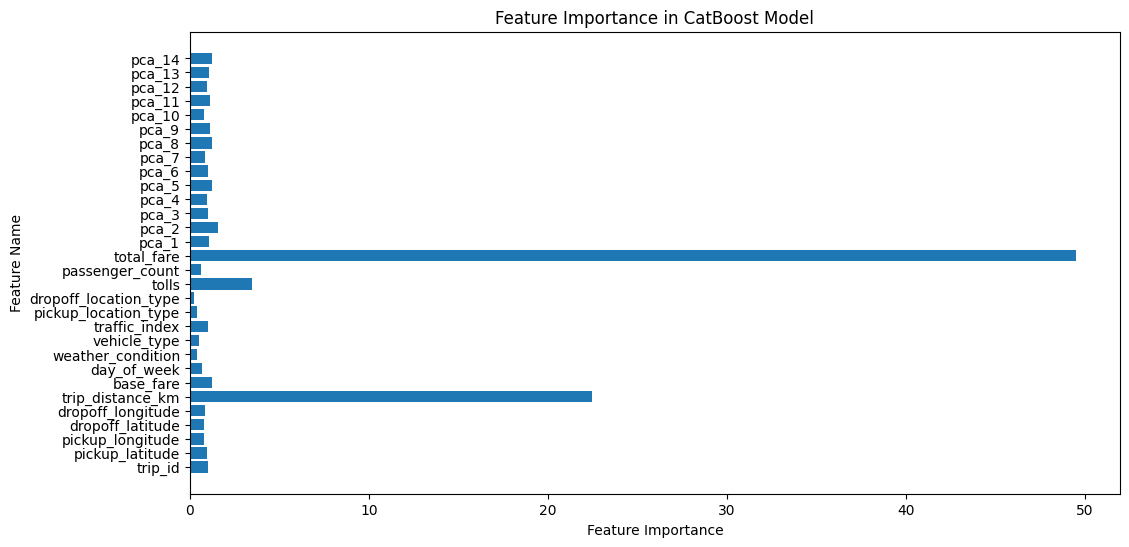

In [81]:
import matplotlib.pyplot as plt

feature_importance = model.get_feature_importance()
feature_names = X_train.columns

plt.figure(figsize=(12,6))
plt.barh(feature_names, feature_importance)
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Feature Importance in CatBoost Model")
plt.savefig("feature_importance1.png", dpi=300)
plt.show()


In [82]:
from google.colab import files
files.download("feature_importance1.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
from catboost import CatBoostRegressor

# Assuming you have 'study' object from Optuna optimization:
best_params = study.best_params  # Get the best parameters from Optuna study

# Initialize model with best parameters from Optuna
best_model = CatBoostRegressor(
    iterations=best_params['iterations'],
    learning_rate=best_params['learning_rate'],
    depth=best_params['depth'],
    l2_leaf_reg=best_params['l2_leaf_reg'],
    random_strength=best_params['random_strength'],
    bagging_temperature=best_params['bagging_temperature'],
    border_count=best_params['border_count'],
    loss_function='RMSE',
    verbose=100,
    early_stopping_rounds=300
)

# Train the model on full dataset
best_model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

0:	learn: 0.9819841	test: 0.9754504	best: 0.9754504 (0)	total: 7.21ms	remaining: 17.2s
100:	learn: 0.5448733	test: 0.5702141	best: 0.5702141 (100)	total: 572ms	remaining: 12.9s
200:	learn: 0.5113975	test: 0.5553866	best: 0.5553866 (200)	total: 1.11s	remaining: 12s
300:	learn: 0.4825685	test: 0.5476550	best: 0.5475455 (298)	total: 1.66s	remaining: 11.5s
400:	learn: 0.4620673	test: 0.5478600	best: 0.5472993 (321)	total: 2.19s	remaining: 10.8s
500:	learn: 0.4427097	test: 0.5477612	best: 0.5472993 (321)	total: 2.73s	remaining: 10.3s
600:	learn: 0.4247700	test: 0.5485461	best: 0.5472993 (321)	total: 3.26s	remaining: 9.68s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.5472992678
bestIteration = 321

Shrink model to first 322 iterations.


In [71]:
### Step 12: Final Prediction and Evaluation
# Generate predictions using the best model

y_pred_best = best_model.predict(X_test)

In [72]:
# Evaluate the best model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_best)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2 = r2_score(y_test, y_pred_best)

# Print results
print(f"📌 Mean Absolute Error (MAE): {mae:.4f}")
print(f"📌 Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"📌 R² Score: {r2:.4f}")



📌 Mean Absolute Error (MAE): 0.3333
📌 Root Mean Squared Error (RMSE): 0.5471
📌 R² Score: 0.6931


In [76]:
# Save model evaluation results
with open("model_evaluation.txt", "w") as f:
    f.write(f"Mean Absolute Error (MAE): {0.3333}\n")
    f.write(f"Root Mean Squared Error (RMSE): {0.5471}\n")
    f.write(f"R² Score: {0.6931}\n")


In [77]:
from google.colab import files
files.download("model_evaluation.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<ipython-input-78-9458aa4599b6>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance[sorted_idx], y=np.array(feature_names)[sorted_idx], palette="viridis")


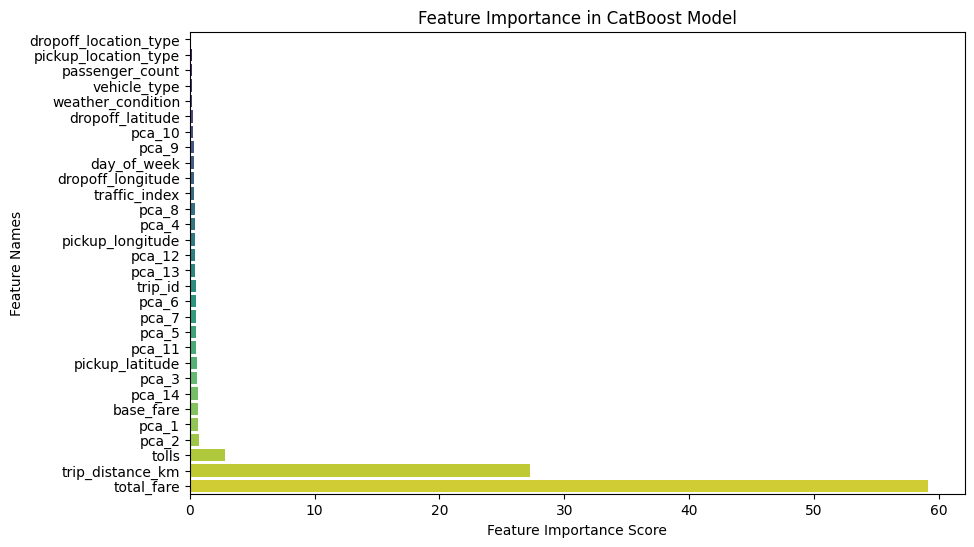

In [78]:
# Feature Importance Plot (for CatBoost)
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = best_model.get_feature_importance()
feature_names = X_train.columns

# Sort features by importance
sorted_idx = np.argsort(feature_importance)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance[sorted_idx], y=np.array(feature_names)[sorted_idx], palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature Names")
plt.title("Feature Importance in CatBoost Model")
# Save plot
plt.savefig("feature_importance.png", dpi=300)
plt.show()



In [79]:
from google.colab import files
files.download("feature_importance.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
import joblib

joblib.dump(best_model, 'best_catboost_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [80]:
from google.colab import files

files.download("best_catboost_model.pkl")




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>